# 05 — 프롬프트 기반 무드 검색 (자동 생성용)

```
프롬프트 → 1위 무드 → gallery Top-2 → (다음) 프롬프트 재구성 → 생성
```

- 한국어 입력 시 자동 영어 번역 후 CLIP 검색
- 기본: **무드 1개 + 레퍼런스 이미지 2장** (중복 cover 제외)
- **출력 개수는 `top_k` 하나만 조절** (예: `top_k=5`). gallery 전체가 검색 후보 (무드당 이미지 수 이하)

**선행:** `04_build_library.ipynb` 실행 완료 (`mood_library/index.json` 필요)

**커널:** `.venv` Python 선택

In [1]:
# torch, transformers 등 (커널이 .venv가 아니면 실행)
%pip install -r ../requirements-ml.txt -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib inline

import importlib
import json
import sys
from pathlib import Path

# notebooks/ 또는 프로젝트 루트 어디서 실행해도 루트 찾기
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "mood_pipeline").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "mood_pipeline").exists():
    raise FileNotFoundError(
        "mood_pipeline 폴더를 찾을 수 없습니다. notebooks/ 또는 프로젝트 루트에서 실행하세요."
    )

sys.path.insert(0, str(PROJECT_ROOT))

# 코드 수정 반영: config → search 순서로 reload (config 캐시가 오래되면 ImportError)
import mood_pipeline.config as config_module
import mood_pipeline.search as search_module

importlib.reload(config_module)
importlib.reload(search_module)

from mood_pipeline.search import (
    build_mood_text_embeddings,
    plot_search_result,
    prepare_prompt_for_search,
    search_mood_with_images,
)

INDEX_PATH = PROJECT_ROOT / "mood_library" / "index.json"
if not INDEX_PATH.exists():
    raise FileNotFoundError(
        f"{INDEX_PATH} 없음 → 먼저 04_build_library.ipynb 를 실행하세요."
    )

print("PROJECT_ROOT:", PROJECT_ROOT)
index_info = build_mood_text_embeddings()
print("search index:", index_info)

c:\Users\jundo\Desktop\창의학기\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT: C:\Users\jundo\Desktop\창의학기
search index: {'mood_count': 8, 'text_embeddings_shape': (8, 512), 'rep_image_count': 361, 'cached': True}


원문: 세련되고 고급스러운 방
검색용(EN): Stylish and luxurious room


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 39303.39it/s]


{
  "prompt_original": "세련되고 고급스러운 방",
  "prompt_en": "Stylish and luxurious room",
  "translated": true,
  "moods": [
    {
      "mood_id": "luxury_modern",
      "id": "luxury_modern_c07",
      "mood_name_ko": "럭셔리 모던",
      "mood_name_en": "luxury modern studio apartment",
      "score": 0.74656742811203
    }
  ],
  "selected_mood": {
    "mood_id": "luxury_modern",
    "id": "luxury_modern_c07",
    "mood_name_ko": "럭셔리 모던",
    "mood_name_en": "luxury modern studio apartment",
    "score": 0.74656742811203
  },
  "recommended_images": [
    {
      "mood_id": "luxury_modern",
      "id": "luxury_modern_c07",
      "mood_name_ko": "럭셔리 모던",
      "filename": "8b2343f568a8.jpg",
      "path": "luxury_modern_c07/gallery/8b2343f568a8.jpg",
      "score": 0.3028509020805359
    },
    {
      "mood_id": "luxury_modern",
      "id": "luxury_modern_c07",
      "mood_name_ko": "럭셔리 모던",
      "filename": "21c17bce67ca.jpg",
      "path": "luxury_modern_c07/gallery/21c17bce67ca.jpg",
 

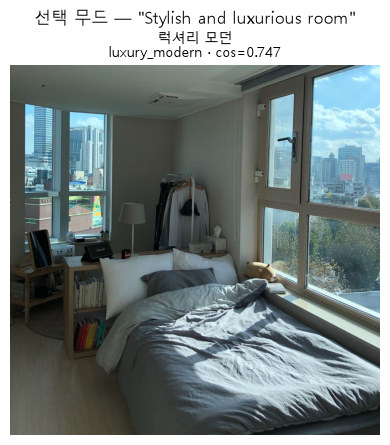

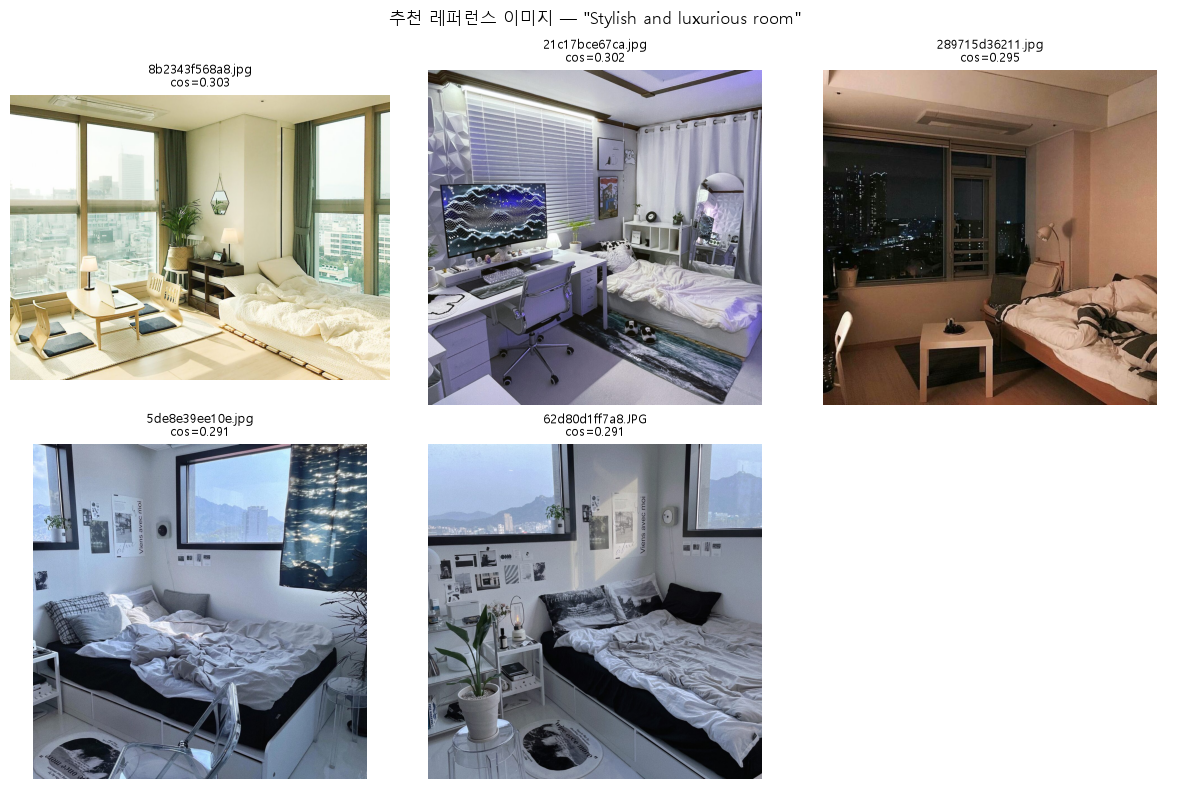

In [ ]:
# ↓ 프롬프트만 바꿔서 실행
prompt = "연구실 스러운 방"

prepared = prepare_prompt_for_search(prompt)
print("원문:", prepared["prompt_original"])
print("검색용(EN):", prepared["prompt_en"])

# ★ gallery 이미지 개수 (5장 원하면 top_k=5)
result = search_mood_with_images(prompt, top_k=5)

# result(dict)를 JSON 문자열로 출력 (디버깅·결과 확인용, figure와 별개)
#   ensure_ascii=False → 한글 그대로 출력
#   indent=2          → 줄바꿈+들여쓰기 칸 수 (None이면 한 줄, 숫자 클수록 더 넓게)
print(json.dumps(result, ensure_ascii=False, indent=2))

plot_search_result(result, prompt=result.get("prompt_en", prompt))